In [4]:
import tensorflow_datasets as tfds

(ds_train, ds_test), ds_info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.GT44UU_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [7]:
#  Preprocessing

IMG_SIZE = 150

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train = ds_train.map(preprocess).batch(32).prefetch(1)
val = ds_test.map(preprocess).batch(32).prefetch(1)


In [8]:
# Simple CNN Model

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train,
    epochs=20,                # keep higher, early stop will cut it early
    validation_data=val,
    callbacks=[early_stop]
)


Epoch 1/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 940s 2s/step - accuracy: 0.5577 - loss: 0.6804 - val_accuracy: 0.7210 - val_loss: 0.5522
Epoch 2/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 951s 2s/step - accuracy: 0.7352 - loss: 0.5269 - val_accuracy: 0.7848 - val_loss: 0.4640
Epoch 3/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 917s 2s/step - accuracy: 0.8049 - loss: 0.4225 - val_accuracy: 0.7979 - val_loss: 0.4371
Epoch 4/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 923s 2s/step - accuracy: 0.8489 - loss: 0.3422 - val_accuracy: 0.8091 - val_loss: 0.4329
Epoch 5/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 905s 2s/step - accuracy: 0.8962 - loss: 0.2502 - val_accuracy: 0.7850 - val_loss: 0.5787
Epoch 6/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 922s 2s/step - accuracy: 0.9257 - loss: 0.1834 - val_accuracy: 0.7934 - val_loss: 0.5708
Epoch 7/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 901s 2s/step - accuracy: 0.9393 - loss: 0.1472 - val_accuracy: 0.7915 - val_loss: 0.6987


In [10]:
#Evaluation

val_loss, val_acc = model.evaluate(val)
print(f"\nValidation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

146/146 ━━━━━━━━━━━━━━━━━━━━ 69s 473ms/step - accuracy: 0.8028 - loss: 0.4490

Validation Loss: 0.4329, Validation Accuracy: 0.8091


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


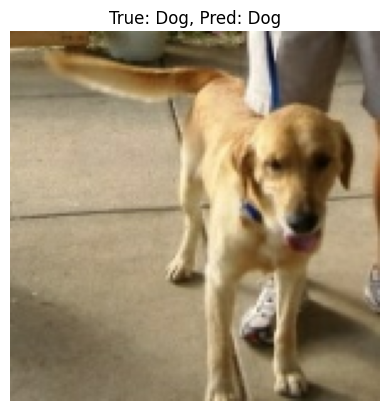

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


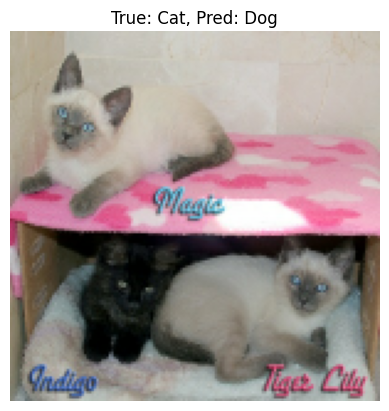

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


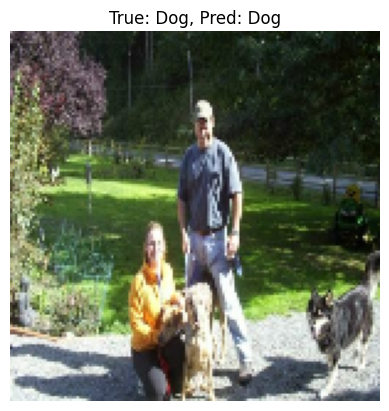

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


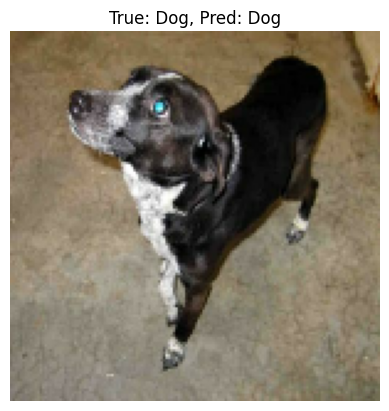

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


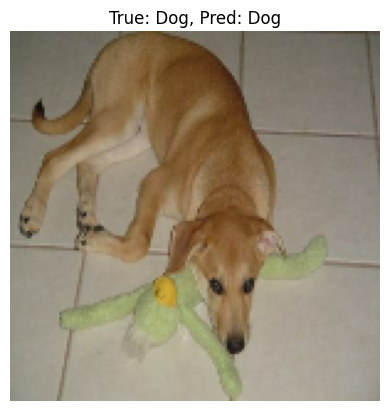

In [12]:
# Sample Predictions

def show_sample_predictions(dataset, num=2):
    dataset_iter = iter(dataset.unbatch().take(num))
    for img, label in dataset_iter:
        pred = model.predict(tf.expand_dims(img, axis=0))[0][0]
        pred_label = "Dog" if pred>0.5 else "Cat"
        true_label = "Dog" if label==1 else "Cat"
        plt.imshow(img.numpy())
        plt.title(f"True: {true_label}, Pred: {pred_label}")
        plt.axis("off")
        plt.show()

show_sample_predictions(val, num=5)

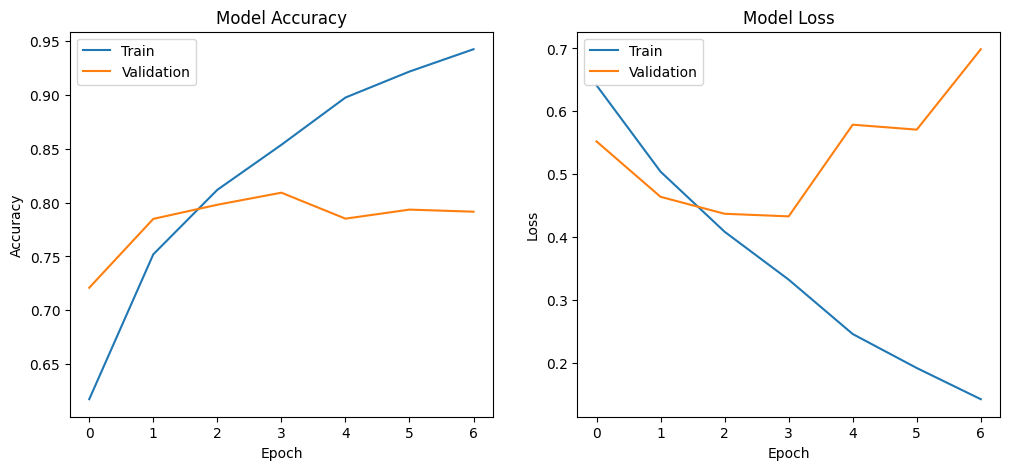

In [13]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()